In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import anndata as ad
from kneed import KneeLocator
import scipy.sparse as sp

In [2]:
# ! pip install kneed

In [3]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
ncells = 4

### 1. Select the guides for analysis

/tmp/ipykernel_1834354/4132653022.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.index, df['IntersectionCount'],


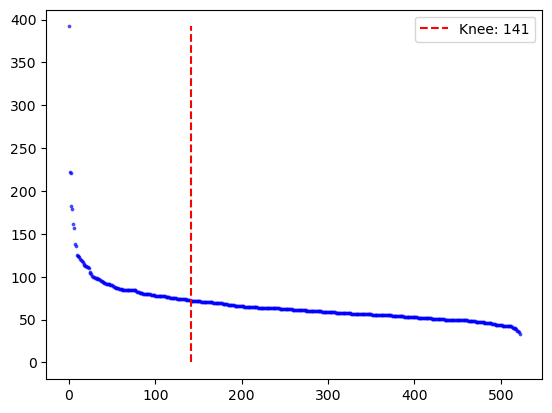

In [5]:

pert_type = "crispri"  # or "crispri"

df = pd.read_csv(f'/home/user/Documents/Kinase_project/{pert_type}_final/deg_ntc_kinases.csv')
plt.scatter(df.index, df['IntersectionCount'], 
            s=3,  # size of points
            c='blue',  # color of points
            alpha=0.6,  # transparency
            cmap='viridis')  # color map

# Increase S to be more strict (e.g., S=15 or S=20)
kn = KneeLocator(df.index, df['IntersectionCount'], curve='convex', direction='decreasing', S=10)
kn.knee

# Plot the knee location
plt.vlines(kn.knee, ymin=0, ymax=df['IntersectionCount'].max(), linestyles='dashed', colors='red', label=f'Knee: {kn.knee}')
plt.legend()
plt.show()

top_kinases = df['Kinase'].head(kn.knee).values
valid_gene_ids = list(top_kinases) + ['NTC']+ ['EPHA2'] + ['PDGFRA']


In [6]:
top_kinases

array(['NRBP1', 'MAP3K7', 'RIOK2', 'MAPKAPK5', 'WNK2', 'MET', 'AURKB',
       'SCYL2', 'RPS6KC1', 'MAP4K1', 'PRKG2', 'RIPK4', 'PRKACG',
       'PIK3C2A', 'MAP3K14', 'IRAK1', 'CDK12', 'CDC42BPA', 'ADCK3',
       'BRDT', 'NPR1', 'TTN', 'BUB1B', 'STK17B', 'ATR', 'STK33',
       'CSNK2A2', 'MAST4', 'SMG1', 'PDGFRA', 'MAK', 'ROCK2', 'MAP3K4',
       'STK35', 'RPS6KA3', 'STYK1', 'PRKCI', 'DAPK3', 'TLK2', 'PDIK1L',
       'MARK1', 'CDK11A', 'CDK3', 'NEK9', 'ERBB4', 'NTRK3', 'SGK2',
       'CDK4', 'SPEG', 'RPS6KA4', 'CDK8', 'AXL', 'CDKL2', 'EPHB2',
       'CSNK1G2', 'CDKL1', 'JAK1', 'TYK2', 'CDK17', 'MAP4K3', 'STK40',
       'PRKDC', 'STRADA', 'WEE1', 'NEK8', 'TESK1', 'PLK1', 'STRADB',
       'PASK', 'NRBP2', 'PKMYT1', 'PRKCZ', 'DAPK2', 'MAPK9', 'PNCK',
       'PIK3CB', 'TGFBR2', 'PRKD1', 'NPR2', 'PIM2', 'BTK', 'BCR', 'KDR',
       'HIPK4', 'EIF2AK3', 'MAP3K5', 'RIPK2', 'TEX14', 'MKNK2', 'PRKCG',
       'IRAK3', 'NEK4', 'WNK3', 'EIF2AK2', 'PEAK1', 'GSK3A', 'C9orf96',
       'MASTL', 'CDK2', 'P

### 2. Prepare TCDG files

In [7]:
df = pd.read_csv(f'/home/user/Documents/Kinase_project/figures/decipher_analysis/NTC_{pert_type}/T_cell_dose_gene.csv')
T_cell_dose_gene = df['gene_short_name']

In [8]:
T_cell_dose_gene

0           GCLC
1         NIPAL3
2            BAD
3           LAP3
4         KLHL13
          ...   
1664       CISD3
1665       DDX52
1666    SND1-IT1
1667     HELLPAR
1668        CDR1
Name: gene_short_name, Length: 1669, dtype: object

### 3. Generate raw and hvg files

In [9]:
gbm= ad.read_h5ad(f'/home/user/Documents/Kinase_project/{pert_type}_final/preprocessed_cds_without_Tcells.h5ad')

In [10]:
gbm

AnnData object with n_obs × n_vars = 182652 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [11]:
# Filter out cells where sgRNA is NA
gbm = gbm[~gbm.obs['sgRNA'].isna()].copy()
gbm

AnnData object with n_obs × n_vars = 182652 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [12]:
gbm.X.max()

2401.0

In [13]:
gbm_crop = gbm[
    (gbm.obs['total_sgrna_read_per_cell'] > 3) & 
    (gbm.obs['top_proportion'] > 0.3)
].copy()
gbm_crop

AnnData object with n_obs × n_vars = 125225 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [14]:
# Quality filter
gbm_crop = gbm_crop[
    (gbm_crop.obs['total_hash_umis_per_cell_ID'] > 1) &
    (gbm_crop.obs['top_to_second_best_ratio'] > 2)
].copy()

In [15]:
filtered_gbm_crop = gbm_crop[gbm_crop.obs['gene_id'].isin(valid_gene_ids)]
print("Filtered gene IDs:", filtered_gbm_crop.obs['gene_id'].unique())

Filtered gene IDs: ['STK35' 'NTC' 'ACVR2B' 'SPEG' 'CDK17' 'HIPK4' 'RPS6KA3' 'WNK2' 'CDK11A'
 'STRADB' 'ADRBK2' 'CSNK1G2' 'RPS6KA4' 'PRKG2' 'FGFR2' 'SBK1' 'STK11'
 'MAP4K1' 'TNK2' 'MOS' 'RPS6KB2' 'GSK3A' 'CDK14' 'RIPK2' 'PKN1' 'DAPK3'
 'TTN' 'TEX14' 'RPS6KC1' 'ICK' 'MAST4' 'STK17B' 'RIPK4' 'TESK2' 'MAPKAPK5'
 'NEK9' 'ADCK3' 'ANKK1' 'MET' 'IRAK1' 'CSNK1G1' 'STK33' 'MAP3K14' 'CDK2'
 'NRBP2' 'MAPK9' 'PASK' 'PNCK' 'RIOK2' 'CDK3' 'TRIM33' 'PRKCG' 'CDKL1'
 'IRAK3' 'CDK8' 'CDK4' 'NPR2' 'EIF2AK3' 'NEK8' 'PIK3CB' 'SCYL2' 'NEK4'
 'WNK3' 'OBSCN' 'EPHA2' 'EPHB4' 'MKNK2' 'MAP3K4' 'ROCK2' 'TGFBR2' 'WEE1'
 'NRBP1' 'SGK2' 'EIF2AK1' 'BMPR1A' 'NTRK3' 'MAP3K13' 'JAK1' 'CHEK2' 'PDK3'
 'MAK' 'PEAK1' 'KDR' 'CSNK2A2' 'EPHB2' 'PRPF4B' 'CSNK1E' 'C9orf96'
 'MAP4K3' 'SMG1' 'MAPK11' 'TYK2' 'TESK1' 'MKNK1' 'PRKACG' 'PRKCD' 'PRKCZ'
 'ALK' 'MAP3K5' 'DAPK2' 'CDC42BPA' 'CDKL2' 'MTOR' 'TLK2' 'TSSK4' 'PRKCI'
 'BUB1B' 'PIK3C2A' 'BTK' 'CDK12' 'EIF2AK2' 'PLK3' 'TAF1' 'STRADA' 'SRPK3'
 'ERBB4' 'KIAA1804' 'NPR1' 'PRKD1' 'ATR'

In [16]:
gene_id_counts = filtered_gbm_crop.obs['gene_id'].value_counts()
gene_id_counts

gene_id
NTC       1859
PRKCZ      417
TNK2       380
STK11      366
MKNK2      337
          ... 
MAP3K7      49
MTOR        38
BUB1B       37
AURKB       18
PLK1        14
Name: count, Length: 143, dtype: int64

In [17]:
# Filter genes with >= 25 cells
valid_gene_ids = gene_id_counts[gene_id_counts >= 50].index
filtered_gbm_crop = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'].isin(valid_gene_ids)]
filtered_gene_id_counts = filtered_gbm_crop.obs['gene_id'].value_counts()
filtered_gene_id_counts

gene_id
NTC      1859
PRKCZ     417
TNK2      380
STK11     366
MKNK2     337
         ... 
AURKA      82
WEE1       80
BCR        64
RIOK2      60
CDK4       51
Name: count, Length: 138, dtype: int64

In [18]:
# Filter NTC cells
ntc_cells = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] == 'NTC']

# Randomly sample NTC cells (Top kinases gene count)
ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=SEED).index
ntc_sampled_adata = filtered_gbm_crop[filtered_gbm_crop.obs.index.isin(ntc_sampled_indices)].copy()

# Filter out NTC cells from the original data to get non-NTC data
non_ntc_adata = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] != 'NTC']

# Combine sampled NTC cells with non-NTC data
combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)
combined_adata

/tmp/ipykernel_1834354/3719994924.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=SEED).index
/tmp/ipykernel_1834354/3719994924.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)


AnnData object with n_obs × n_vars = 23634 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'batch'
    var: 'features'

In [19]:
# Filter NTC cells
ntc_cells = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] == 'NTC']

# Randomly sample 489 NTC cells (Top kinases gene count)
ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=1).index
ntc_sampled_adata = filtered_gbm_crop[filtered_gbm_crop.obs.index.isin(ntc_sampled_indices)].copy()

# Filter out NTC cells from the original data to get non-NTC data
non_ntc_adata = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] != 'NTC']

# Combine sampled NTC cells with non-NTC data
combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)
combined_adata

/tmp/ipykernel_1834354/976759071.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=1).index
/tmp/ipykernel_1834354/976759071.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)


AnnData object with n_obs × n_vars = 23634 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'batch'
    var: 'features'

In [20]:
combined_adata.obs['gene_id'].value_counts()

gene_id
PRKCZ    417
NTC      417
TNK2     380
STK11    366
MKNK2    337
        ... 
AURKA     82
WEE1      80
BCR       64
RIOK2     60
CDK4      51
Name: count, Length: 138, dtype: int64

In [21]:
combined_adata.obs['treatment']        = combined_adata.obs['dose'].replace({1.: '1to1', 0.5: '1to0.5', 0.25: '1to0.25', 0.: 'Untreated'})
combined_adata.obs['treatment_geneid'] = combined_adata.obs['treatment'].astype(str) + '_' + combined_adata.obs['gene_id'].astype(str)

In [22]:
def make_metacells_bootstrap(adata, groupby='treatment_geneid', n_cells=10,
                              n_metacells=30, seed=42, layer=None):
    """Bootstrap metacells: sample n_cells without replacement, n_metacells times per group."""
    X = adata.layers[layer] if layer else adata.X
    if sp.issparse(X):
        X = X.toarray()
    rng = np.random.default_rng(seed)
    rows, obs_records = [], []
    for _, grp in adata.obs.groupby(groupby):
        cell_idx = [adata.obs_names.get_loc(i) for i in grp.index]
        if len(cell_idx) < n_cells:
            continue
        for _ in range(n_metacells):
            sampled = rng.choice(cell_idx, size=n_cells, replace=False)
            rows.append(X[sampled].sum(axis=0))
            meta = {col: grp[col].iloc[0] for col in ['gene_id', 'treatment', 'treatment_geneid', 'dose']}
            meta['n_cells_summed'] = n_cells
            obs_records.append(meta)
    return ad.AnnData(
        X=np.vstack(rows),
        obs=pd.DataFrame(obs_records).reset_index(drop=True),
        var=adata.var.copy()
    )

In [23]:
adata_meta = make_metacells_bootstrap(combined_adata, groupby='treatment_geneid', n_cells=ncells, n_metacells=30, seed=SEED)
print(adata_meta)
print(adata_meta.obs['treatment_geneid'].value_counts())

/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 16560 × 56648
    obs: 'gene_id', 'treatment', 'treatment_geneid', 'dose', 'n_cells_summed'
    var: 'features'
treatment_geneid
Untreated_WNK3      30
1to0.25_ABL1        30
1to0.25_ACVR2B      30
1to0.25_ADCK3       30
1to0.25_ADRBK2      30
                    ..
1to0.25_BRDT        30
1to0.25_BTK         30
1to0.25_C9orf96     30
1to0.25_CDC42BPA    30
1to0.25_CDK11A      30
Name: count, Length: 552, dtype: int64


In [24]:
# Use only untreated cells for DEG
untreated_cells = adata_meta[adata_meta.obs['treatment'] == 'Untreated'].copy()

In [25]:
sc.pp.normalize_total(untreated_cells)
sc.pp.log1p(untreated_cells)

sc.tl.rank_genes_groups(
    untreated_cells, groupby='gene_id', reference='NTC',
    use_raw=False, method='wilcoxon'
)
print('DEG done.')

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmente

DEG done.


In [26]:
deg_df = sc.get.rank_genes_groups_df(untreated_cells, group=None, key='rank_genes_groups')

sig_raw = deg_df[deg_df['pvals'] < 0.05].sort_values(['group', 'pvals']).reset_index(drop=True)
sig_adj = deg_df[deg_df['pvals_adj'] < 0.05].sort_values(['group', 'pvals_adj']).reset_index(drop=True)

print(f'DEGs (raw p<0.05):  {len(sig_raw["names"].unique())} unique genes, {sig_raw["group"].nunique()} perturbations')
print(f'DEGs (FDR<0.05):    {len(sig_adj["names"].unique())} unique genes, {sig_adj["group"].nunique()} perturbations')

DEGs (raw p<0.05):  14856 unique genes, 137 perturbations
DEGs (FDR<0.05):    6532 unique genes, 132 perturbations


In [27]:
# DEG count per perturbation (FDR < 0.05)
deg_counts = sig_adj.groupby('group', observed=True).size().sort_values(ascending=False)
print('DEG count per perturbation (FDR<0.05):')
print(deg_counts.to_string())

DEG count per perturbation (FDR<0.05):
group
CDK4        1445
TSSK4       1111
TLK2         827
SMG1         826
NTRK3        807
RIOK2        598
MASTL        593
BCR          567
MET          543
CDK11A       531
WEE1         526
NLK          441
CSNK2A1      441
KDR          401
PRKACG       364
PRKDC        343
ROS1         343
AURKA        338
PRKCG        287
MOS          285
PDGFRA       273
BRDT         264
NEK4         239
SRPK3        221
PLK3         209
PDK3         205
MAP3K5       204
CDKL2        200
EPHA2        197
PIK3CB       190
PRKG2        188
AXL          186
ATR          185
NEK9         175
CDK8         162
CDK12        159
CDK2         158
PKMYT1       156
PRPF4B       155
JAK1         130
STYK1        125
NRBP1        122
MAPK11       120
PIK3C2A      117
ADCK3         99
PNCK          97
STK35         97
WNK3          96
NPR2          93
FGFR2         90
RPS6KC1       88
CDC42BPA      87
EPHB2         80
C9orf96       75
RIPK2         75
MAP3K14       70
ALK

In [28]:
# How many perturbations have at least 1 DEG?
n_with_degs = (deg_counts > 0).sum()
total_perts = untreated_cells.obs['gene_id'].nunique() - 1  # exclude NTC
print(f'Perturbations with >=1 DEG (FDR<0.05): {n_with_degs} / {total_perts}')
print(f'Perturbations with >=5 DEGs:           {(deg_counts >= 5).sum()} / {total_perts}')
print(f'Perturbations with >=10 DEGs:          {(deg_counts >= 10).sum()} / {total_perts}')

Perturbations with >=1 DEG (FDR<0.05): 132 / 137
Perturbations with >=5 DEGs:           123 / 137
Perturbations with >=10 DEGs:          112 / 137


In [38]:
# Guides (perturbations) with more than 50 significant DEGs (FDR<0.05)
guides_over_50 = deg_counts[deg_counts > 50].index
print(f'Guides with >50 DEGs: {len(guides_over_50)} / {len(deg_counts)}')
print(guides_over_50.tolist())

Guides with >50 DEGs: 71 / 132
['CDK4', 'TSSK4', 'TLK2', 'SMG1', 'NTRK3', 'RIOK2', 'MASTL', 'BCR', 'MET', 'CDK11A', 'WEE1', 'NLK', 'CSNK2A1', 'KDR', 'PRKACG', 'PRKDC', 'ROS1', 'AURKA', 'PRKCG', 'MOS', 'PDGFRA', 'BRDT', 'NEK4', 'SRPK3', 'PLK3', 'PDK3', 'MAP3K5', 'CDKL2', 'EPHA2', 'PIK3CB', 'PRKG2', 'AXL', 'ATR', 'NEK9', 'CDK8', 'CDK12', 'CDK2', 'PKMYT1', 'PRPF4B', 'JAK1', 'STYK1', 'NRBP1', 'MAPK11', 'PIK3C2A', 'ADCK3', 'PNCK', 'STK35', 'WNK3', 'NPR2', 'FGFR2', 'RPS6KC1', 'CDC42BPA', 'EPHB2', 'C9orf96', 'RIPK2', 'MAP3K14', 'ALK', 'EIF2AK1', 'EIF2AK2', 'TYK2', 'DAPK2', 'MAP4K3', 'TRIM33', 'ABL1', 'CSNK1G1', 'EPHB4', 'ANKK1', 'PIM2', 'PRKD3', 'BMPR1A', 'DAPK3']


In [39]:
# Top 50 DEGs (by FDR) for guides with >50 significant DEGs
top50_deg_df = (
    sig_adj[sig_adj['group'].isin(guides_over_50)]
    .groupby('group', observed=True)
    .head(100)
)
print(top50_deg_df.groupby('group', observed=True).size().to_string())

group
ABL1         60
ADCK3        99
ALK          70
ANKK1        54
ATR         100
AURKA       100
AXL         100
BCR         100
BMPR1A       53
BRDT        100
C9orf96      75
CDC42BPA     87
CDK2        100
CDK4        100
CDK8        100
CDK11A      100
CDK12       100
CDKL2       100
CSNK1G1      59
CSNK2A1     100
DAPK2        66
DAPK3        52
EIF2AK1      70
EIF2AK2      68
EPHA2       100
EPHB2        80
EPHB4        56
FGFR2        90
JAK1        100
KDR         100
MAP3K5      100
MAP3K14      70
MAP4K3       63
MAPK11      100
MASTL       100
MET         100
MOS         100
NEK4        100
NEK9        100
NLK         100
NPR2         93
NRBP1       100
NTRK3       100
PDGFRA      100
PDK3        100
PIK3C2A     100
PIK3CB      100
PIM2         54
PKMYT1      100
PLK3        100
PNCK         97
PRKACG      100
PRKCG       100
PRKD3        53
PRKDC       100
PRKG2       100
PRPF4B      100
RIOK2       100
RIPK2        75
ROS1        100
RPS6KC1      88
SMG1        100
SR

In [43]:
top50_deg_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ABL1,AL354740.1,5.204118,3.756041,1.949204e-07,0.007578
1,ABL1,TM9SF2,-5.144980,-1.305229,2.675492e-07,0.007578
2,ABL1,RGL1,5.056273,2.281443,4.275281e-07,0.008073
3,ABL1,PACSIN2,4.960175,2.348301,7.042980e-07,0.008635
4,ABL1,SPP1,4.937998,1.343078,7.892862e-07,0.008635
...,...,...,...,...,...,...
19127,WNK3,ZNF280D,3.969618,1.748418,7.198788e-05,0.044326
19128,WNK3,SRI,-3.962226,-2.508706,7.425420e-05,0.045230
19129,WNK3,CCDC82,3.947442,2.156787,7.899078e-05,0.047603
19130,WNK3,ACAD9,3.932657,1.936579,8.401202e-05,0.049574


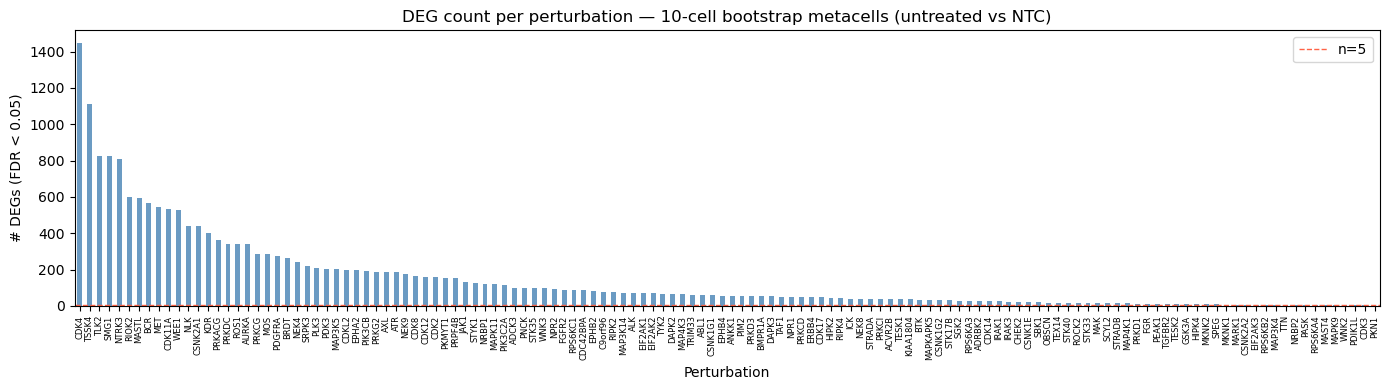

In [40]:
# Bar chart of DEG counts per perturbation
fig, ax = plt.subplots(figsize=(14, 4))
deg_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Perturbation')
ax.set_ylabel('# DEGs (FDR < 0.05)')
ax.set_title('DEG count per perturbation — 10-cell bootstrap metacells (untreated vs NTC)')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.axhline(5, color='tomato', lw=1, ls='--', label='n=5')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

In [41]:
import pyreadr
result = pyreadr.read_r('/home/user/Documents/Githubs/PerturbVAE/sherlock/datasets/gbm/KinMap_kinase_protein_to_gene_map.rds')
res = result[None]  # RDS files contain only one object, so we use None as key
res = res[res['gene_id'].isin(adata_meta.obs.gene_id.unique())]
kinase_names = res['gene_short_name']

In [44]:
deg_set = set(map(str, top50_deg_df['names']))
kinase_set = set(map(str, kinase_names))
#tcdg_set = set(map(str, T_cell_dose_gene))

union_set =  deg_set | kinase_set #| tcdg_set
union_list = sorted(union_set)

print(f"deg_genes:        {len(deg_set)} genes")
print(f"kinase_genes:     {len(set(kinase_names))} genes")
#print(f"T_cell_dose_genes: {len(tcdg_set)} genes")
print(f"union:            {len(union_set)} genes")

deg_genes:        2874 genes
kinase_genes:     137 genes
union:            2979 genes


In [45]:
combined_adata_tcdg = adata_meta[:, adata_meta.var['features'].isin(union_list)].copy()
combined_adata_tcdg

AnnData object with n_obs × n_vars = 16560 × 2979
    obs: 'gene_id', 'treatment', 'treatment_geneid', 'dose', 'n_cells_summed'
    var: 'features'

In [46]:
combined_adata_tcdg.var.rename(columns={'_index':'index'},inplace=True)
combined_adata_tcdg.write_h5ad(f'/home/user/Documents/Githubs/PerturbVAE_lingting/sherlock/datasets/gbm/filtered_gbm_{pert_type}_crop_top_bootstrap_{ncells}.h5ad')

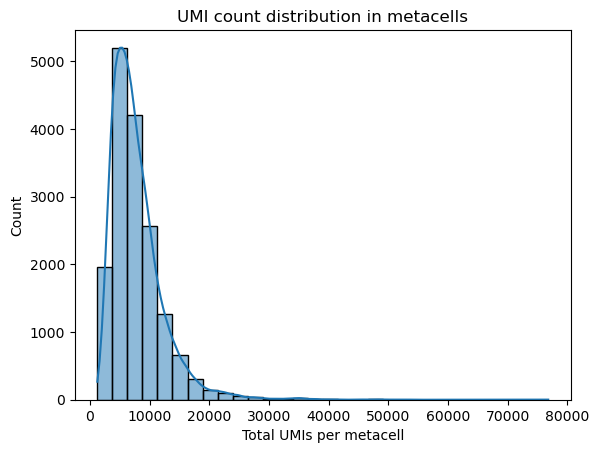

In [47]:
# what is the umi count distribution in the metacells?
combined_adata_tcdg.obs['total_umis'] = combined_adata_tcdg.X.sum(axis=1)
sns.histplot(combined_adata_tcdg.obs['total_umis'], bins=30, kde=True)
plt.xlabel('Total UMIs per metacell')
plt.title('UMI count distribution in metacells')
plt.show()

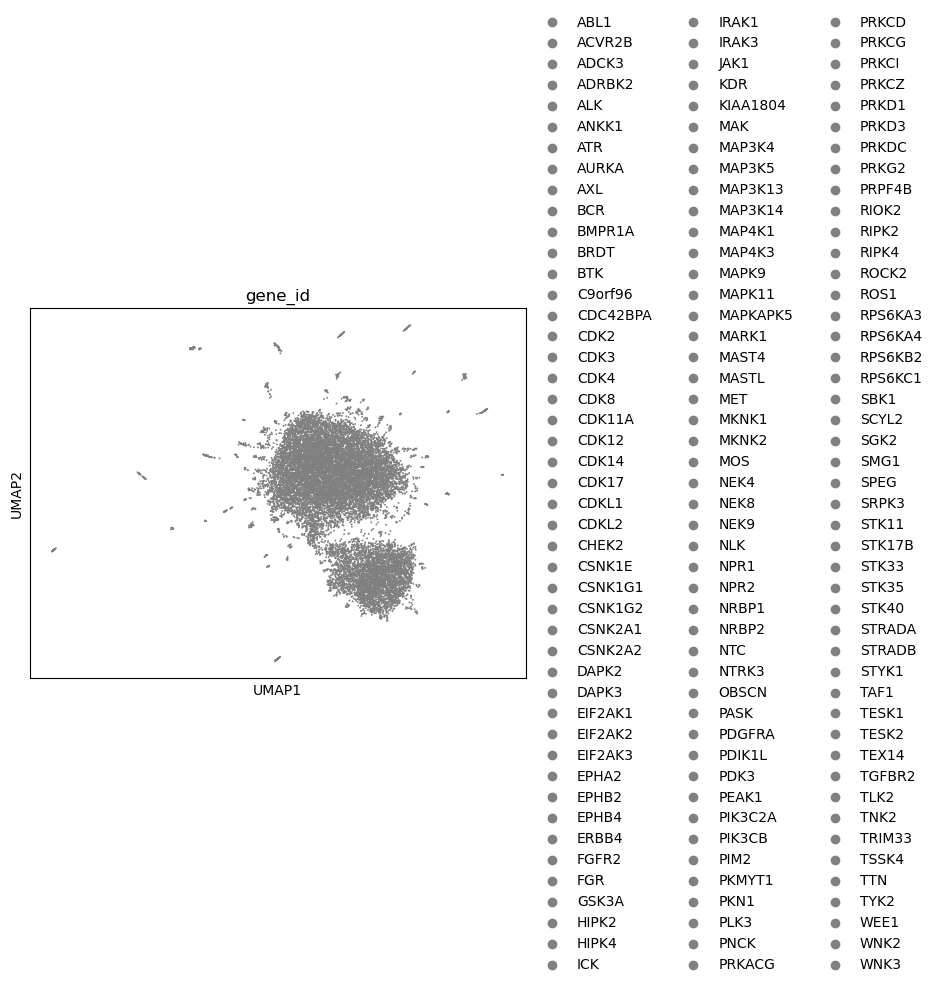

In [35]:
sc.pp.normalize_total(combined_adata_tcdg)
sc.pp.log1p(combined_adata_tcdg)
sc.pp.pca(combined_adata_tcdg, random_state=SEED)

sc.pp.neighbors(combined_adata_tcdg, random_state=SEED)
sc.tl.umap(combined_adata_tcdg, random_state=SEED)
sc.pl.umap(combined_adata_tcdg, color=['gene_id'])

In [36]:
combined_adata_tcdg.obs.dose = combined_adata_tcdg.obs.dose.astype(str)       

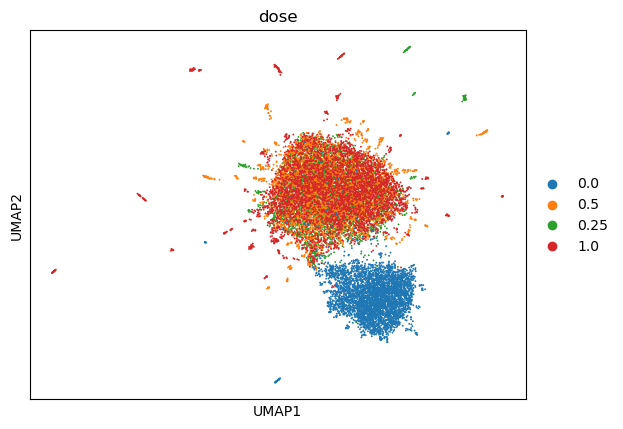

In [37]:
sc.pl.umap(combined_adata_tcdg, color=['dose'])